In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Integral Calculus

Differentiation answered a local question: how does a function change when we
nudge its input? Integration answers a global one: how much of something is
there in total, whether the area under a curve, the volume under a surface, or
the probability under a density. The two look unrelated, yet the *fundamental
theorem of calculus* joins them into a single subject: integration is
differentiation run backwards. That one fact is what makes integrals
computable at all, and it is the reason a deep-learning reader needs them, since
every continuous probability is an integral and every expectation is an integral
average (that section).

We will not need the full machinery of a calculus course. This section builds
what an integral *is* (a limit of sums, extended to unbounded domains), the
fundamental theorem that lets us *compute* integrals together with the
integration-by-parts and change-of-variables rules it yields, and the
multiple-integral toolkit (Fubini's theorem and the $n$-dimensional change of
variables) that powers the Gaussian normalizer and, later, normalizing flows
(that section). The last part turns to
probability: densities, expectations, Monte Carlo estimation, and
differentiation under the integral sign.

In [1]:
%matplotlib inline
from d2l import torch as d2l
import numpy as np
import torch

## The Definite Integral

Take a function $f$ and ask for the area trapped between its graph and the
$x$-axis over an interval $[a, b]$. The area under an entire curve is usually
infinite or undefined, so we always pin it between two endpoints. The recipe is
the same one Archimedes used: chop $[a,b]$ into $N$ thin vertical slices of width
$\epsilon = (b-a)/N$, approximate each slice by a rectangle of height $f(x_i)$,
and add them up. As the slices shrink, the staircase of rectangles squeezes onto
the curve and the sum approaches a definite number, shown in
the figure.

![Left to right: the area under $f$ from $a$ to $b$ approximated by rectangles of shrinking width $\epsilon$. As $\epsilon\to 0$ the rectangle sum $\sum_i \epsilon\,f(x_i)$ converges to the definite integral, the exact signed area.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-cal-riemann.svg)

We *define* the **definite integral** as this limit and write it with the
elongated-$S$ symbol,

$$
\int_a^b f(x)\,dx = \lim_{\epsilon\to 0}\ \sum_i \epsilon\, f(x_i),
$$

a continuous analogue of a sum: $\sum$ becomes $\int$, the spacing $\epsilon$
becomes $dx$, and the term $f(x_i)$ becomes $f(x)$. The inner variable is a dummy,
exactly like a summation index, so $\int_a^b f(x)\,dx = \int_a^b f(z)\,dz$. We
grant the following facts about this limit once and for all
[@Folland.1999]. For bounded, piecewise-continuous $f$ (continuous except
at finitely many jump points), which covers everything we meet in machine
learning, the limit exists and does not depend on how the slices are chosen.
The integral it defines is *monotone*, so $f \le g$ implies
$\int_a^b f\,dx \le \int_a^b g\,dx$, and *additive over subintervals*, so
$\int_a^c f\,dx = \int_a^b f\,dx + \int_b^c f\,dx$ for $a\le b\le c$; both are
plausible from the rectangle picture, and we use both below. (Some hypothesis
on $f$ is genuinely needed: for the function that is $1$ on the rationals and
$0$ elsewhere, the rectangle sums never settle on any value at all. Lebesgue's
integral, built on measure theory rather than on slicing the axis, handles even
that function, assigning it integral $0$ because the rationals have measure
zero, and it is the foundation probability theory ultimately stands on; the
Riemann picture suffices for every computation in this book.)

The definition is not yet a *computation*: only the simplest
integrands (a line, $\int_a^b x\,dx$) succumb to summing the rectangles by hand.
The next section gives the tool that computes the rest. First let us check that
the limit the equation is real by watching it converge. Take
$\int_0^2 \tfrac{x}{1+x^2}\,dx$, whose exact value is $\tfrac12\log 5$ (we will
see why shortly), and refine the partition: the rectangle sum should march toward
the truth, with the error shrinking roughly in proportion to $\epsilon$ for this
left-endpoint rule.

In [2]:
import numpy as onp
def riemann(eps, a=0., b=2.):
    x = onp.arange(a, b, eps)
    return float(onp.sum(eps * x / (1 + x**2)))

truth = float(onp.log(onp.array(5.)) / 2)
for eps in [0.5, 0.1, 0.05, 0.01, 0.001]:
    approx = riemann(eps)
    print(f'eps={eps:<6} sum={approx:.6f}  error={abs(approx - truth):.6f}')
print(f'truth = (1/2) log 5 = {truth:.6f}')

eps=0.5    sum=0.680769  error=0.123950
eps=0.1    sum=0.783785  error=0.020934
eps=0.05   sum=0.794486  error=0.010233
eps=0.01   sum=0.802710  error=0.002009
eps=0.001  sum=0.804519  error=0.000200
truth = (1/2) log 5 = 0.804719


The error falls by about a factor of ten each time we cut $\epsilon$ by ten,
confirming the first-order convergence of the left-rule. Refining the partition
*works*, but it is slow and gives no closed form. We need a better idea.

## The Fundamental Theorem of Calculus

The breakthrough is to stop treating the integral as a fixed number and instead
let its upper limit *move*. Define the **area-so-far function**

$$
F(x) = \int_a^x f(y)\,dy,
$$

the signed area accumulated from the left endpoint $a$ out to $x$. This single
function captures *every* definite integral at once: the area over any
sub-interval is a difference of accumulated areas,

$$
\int_c^b f(x)\,dx = F(b) - F(c),
$$

since the area out to $b$ minus the area out to $c$ leaves exactly the area
between them. the figure draws this subtraction,
accumulating from a base point $c$ at the left edge of the plot.

![The area under $f$ from $a$ to $b$ as the difference of two areas accumulated from a base point $c$ at the plot's left edge: $\int_a^b f\,dx = \int_c^b f\,dx - \int_c^a f\,dx$. Every definite integral is a difference of two values of a single accumulation function.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-cal-sub-area.svg)

So knowing $F$ solves the whole problem. The *fundamental theorem of calculus*
is the fact that $F$ is determined by a derivative.

**Theorem (Fundamental theorem of calculus).** *Let $f$ be continuous and let
$F(x)=\int_a^x f(y)\,dy$. Then $F$ is differentiable and*

$$
\frac{dF}{dx}(x) = f(x).
$$

**Proof.** Differentiate $F$ from the definition: nudge $x$ by $\epsilon$ and
read off how much new area appears. By the equation and additivity of
the integral, the increment is a single thin sliver,

$$
F(x+\epsilon) - F(x) = \int_x^{x+\epsilon} f(y)\,dy .
$$

The sliver sits over an interval of width $\epsilon$. Write
$m_\epsilon = \inf_{[x,x+\epsilon]} f$ and
$M_\epsilon = \sup_{[x,x+\epsilon]} f$ for the tightest constant bounds on $f$
there. Comparing $f$ with those two constants, monotonicity of the integral
pins the sliver between two rectangles of width $\epsilon$:

$$
\epsilon\, m_\epsilon
\ \le\ F(x+\epsilon) - F(x)\ \le\
\epsilon\, M_\epsilon .
$$

Divide by $\epsilon$. Because $f$ is continuous at $x$, for any $\delta>0$ the
whole interval $[x,x+\epsilon]$ eventually lies where $|f(y)-f(x)|<\delta$, so
$m_\epsilon$ and $M_\epsilon$ both converge to the single value
$f(x)$ as $\epsilon \to 0$, and the squeeze forces
$\lim_{\epsilon\to 0}\frac{F(x+\epsilon)-F(x)}{\epsilon}=f(x)$ (for
$\epsilon<0$ the sliver sits to the left of $x$ and the same bounds apply, with
both sign flips canceling in the quotient). That limit is
exactly $F'(x)$. $\blacksquare$

The sliver argument is the whole story: the rate at which accumulated area grows
is just the current height of the curve. This *reverses* the problem. Finding
areas, hard on its own, becomes the search for an **antiderivative**, a function
whose derivative is $f$, which we can read straight off the derivative table of
that section. If $G'=f$ then $G$ and $F$ differ by a
constant (they have the same derivative), and since that constant cancels in any
difference,

$$
\int_a^b f(x)\,dx = G(b) - G(a)
$$

for *any* antiderivative $G$. The arbitrary constant of integration is real but
irrelevant to definite integrals.

This turns hard sums into easy lookups. The derivative of $x^n$ is $nx^{n-1}$, so
running it backwards,

$$
\int_0^{x} n\,y^{n-1}\,dy = x^n - 0^n = x^n ,
$$

and since $e^x$ is its own derivative,

$$
\int_0^{x} e^{t}\,dt = e^{x} - e^{0} = e^x - 1 .
$$

Every integration rule is a differentiation rule read in reverse, which is why
the running example obeyed $\int_0^2 x/(1+x^2)\,dx=\tfrac12\log 5$: the
antiderivative of $x/(1+x^2)$ is $\tfrac12\log(1+x^2)$, evaluated at the
endpoints. Let us confirm the theorem numerically by checking that the
area-so-far function $F$ has derivative $f$: compute $F$ as a cumulative Riemann
sum, finite-difference it, and compare against $f$ itself.

In [3]:
import numpy as onp
f = lambda t: t / (1 + t**2)
G = lambda t: onp.log(1 + t**2) / 2          # antiderivative: F(x) = G(x) - G(0)
eps = 1e-3
x = onp.arange(0., 2., eps)
F = onp.cumsum(eps * f(x))                    # area-so-far via Riemann sum
dFdx = (F[1:] - F[:-1]) / eps                # telescopes to f(x[1:]) exactly
print('max |dF/dx - f|      :', float(onp.abs(dFdx - f(x[1:])).max()))
print('Riemann F(2) vs G(2)-G(0):', float(F[-1]), float(G(onp.array(2.))))

max |dF/dx - f|      : 5.551115123125783e-14
Riemann F(2) vs G(2)-G(0): 0.8045188628837103 0.8047189562170501


The first comparison is exact in exact arithmetic: differencing the cumulative
sum *telescopes*, $F(x+\epsilon)-F(x)$ collapsing back to the single term
$\epsilon f(x+\epsilon)$ that the sum just added. The printed error, a few
parts in $10^{5}$, is therefore not discretization error at all but pure
float32 roundoff in the accumulated $F$, amplified by the division by
$\epsilon$. The Riemann total $F(2)$ agrees with the antiderivative value
$G(2)$ to about $2\times 10^{-4}$, the expected first-order bias of the
left-endpoint rule.

### Improper Integrals

Many densities live on an unbounded domain (the Gaussian, the exponential, any
heavy tail), so we will need to integrate "all the way to infinity," yet
the equation only defined integrals over a finite $[a,b]$. We fill the
gap the same way we defined the integral itself: as a limit. The **improper
integral** is

$$
\int_a^\infty f(x)\,dx = \lim_{b\to\infty}\int_a^b f(x)\,dx ,
$$

with $\int_{-\infty}^\infty$ defined by splitting at any point and requiring
*both* one-sided limits to exist on their own (a symmetric combination of the
two is not enough). The limit may be finite, in which case the integral
*converges*;
otherwise, whether the partial integrals grow without bound or merely fail to
settle, it *diverges*. Whether the tail is "thin enough" is a
genuine question. The test case is the power law $x^{-p}$, for which the
antiderivative gives

$$
\int_1^\infty x^{-p}\,dx = \lim_{b\to\infty}\frac{b^{1-p}-1}{1-p}
= \begin{cases} \dfrac{1}{p-1}, & p>1\ \text{(converges)},\\[1ex] \infty, & p\le 1\ \text{(diverges)}.\end{cases}
$$

The antiderivative $\tfrac{b^{1-p}-1}{1-p}$ is the $0/0$ indeterminate form at
exactly $p=1$, where the integrand $x^{-1}$ has antiderivative $\log x$ instead, so
$\int_1^\infty x^{-1}\,dx=\lim_{b\to\infty}\log b=\infty$; the case split above
already records this divergent value. So $\int_1^\infty x^{-2}\,dx = 1$ while
$\int_1^\infty x^{-1}\,dx=\infty$: the boundary between convergence and divergence
sits exactly at $p=1$. This single threshold is what decides whether a
*heavy-tailed* density, one whose tail decays like a power law rather than
exponentially, even has a finite
normalizer or mean, a recurring concern once we reach probability. The cell
watches a convergent improper integral, $\int_0^\infty e^{-x}\,dx = 1$, through
two lenses at once: the *exact* partial integrals
$\int_0^b e^{-x}\,dx = 1-e^{-b}$, read off the antiderivative, and a
left-Riemann approximation of each with $\epsilon = 10^{-3}$.

In [4]:
import numpy as onp
for b in [1., 2., 5., 10., 20.]:
    x = onp.arange(0., b, 1e-3)
    left = float(onp.sum(1e-3 * onp.exp(-x)))
    exact = 1 - float(onp.exp(onp.array(-b)))
    print(f'b={b:<4}  left-Riemann sum={left:.6f}  exact 1-e^-b={exact:.6f}')

b=1.0   left-Riemann sum=0.632437  exact 1-e^-b=0.632121
b=2.0   left-Riemann sum=0.865097  exact 1-e^-b=0.864665
b=5.0   left-Riemann sum=0.993759  exact 1-e^-b=0.993262
b=10.0  left-Riemann sum=1.000455  exact 1-e^-b=0.999955
b=20.0  left-Riemann sum=1.000500  exact 1-e^-b=1.000000


Read the two columns against each other. The exact partials approach $1$
quickly: the
*truncation error* of stopping at $b$ is $e^{-b}$, already invisible at six
decimals by $b=20$. The left-Riemann column tells a subtler story: it
overshoots and settles near $1.0005$, not $1$. That residue is *discretization
error*. The left rule samples each slice at its left edge, where the decreasing
integrand $e^{-x}$ is largest, so every rectangle overcounts slightly; the
overcounts add up to a bias of
$\approx \tfrac{\epsilon}{2}\bigl(f(0)-f(b)\bigr) \to \tfrac{\epsilon}{2}
= 0.0005$. The two error sources are independent knobs: growing $b$ removes
the first, shrinking $\epsilon$ the second, and no amount of turning one
compensates for neglecting the other.

### Integration by Parts

The fundamental theorem turns every differentiation rule into an integration
rule. Converted, the product rule becomes integration by parts.

**Proposition (Integration by parts).** *For continuously differentiable $u$
and $v$ on $[a,b]$,*

$$
\int_a^b u(x)\,v'(x)\,dx
= \Bigl[\,u(x)\,v(x)\,\Bigr]_a^b - \int_a^b u'(x)\,v(x)\,dx ,
$$

*where $[\,h(x)\,]_a^b$ abbreviates $h(b)-h(a)$.*

**Proof.** By the product rule, $uv$ is an antiderivative of $u'v + uv'$, so
the equation gives
$\int_a^b (u'v + uv')\,dx = [\,u(x)v(x)\,]_a^b$; subtract $\int_a^b u'v\,dx$
from both sides. $\blacksquare$

The formula is a *trade*, not an evaluation: it moves the derivative from one
factor onto the other, which helps whenever the new integrand
$u'v$ is simpler than the old one $uv'$. The model example takes $u(x)=x$ and
$v'(x)=e^{-x}$, so that $u'=1$ and $v=-e^{-x}$: applying
the equation on $[0,b]$ and letting $b\to\infty$,

$$
\int_0^\infty x\,e^{-x}\,dx
= \Bigl[\,-x\,e^{-x}\,\Bigr]_0^\infty + \int_0^\infty e^{-x}\,dx
= 0 + 1 = 1 .
$$

The boundary term vanishes because $x e^{-x}\to 0$ at both ends, and what
survives is exactly the improper integral computed above. This particular
value is the mean of the exponential distribution
(that section), and it shows the form in which the trick
returns throughout probability: expectations $\int g(x)\,p(x)\,dx$ are
integrals of products, and shifting a derivative from a factor we cannot handle
onto one we can is often the only move available. The identity returns in
Hyvärinen's score matching [@Hyvarinen.2005]
(that section), where a single integration
by parts converts an objective involving the score of the data
distribution, the gradient $\nabla_{\mathbf{x}} \log p(\mathbf{x})$ of the
log-density with respect to the *data point*, which no one can evaluate,
into one that can be estimated from samples.

### A Note on Signed Area

The evaluation rule the equation produces negative numbers,
which can be jarring if "area" is supposed to be positive. The resolution is that
integrals measure *signed* area, governed by two independent sign rules. First,
where $f<0$ the area counts as negative: $\int_0^1 (-1)\,dx = -1$. Second,
integrating right-to-left negates the result: $\int_b^a f = -\int_a^b f$. Each
flip, reflecting across the $x$-axis or reversing the limits, introduces one
minus sign; the figure shows both rules on one curve. Apply
them in turn to a single example: $\int_0^{-1} 1\,dx = -1$ (one
flip, from reversed limits), while $\int_0^{-1}(-1)\,dx = 1$ (two flips, which
cancel). This is the same signed-area convention the
determinant followed for transformed regions in
that section, and it is exactly what makes the
change-of-variables formula below come out right.

![Signed area. Lobes above the axis count positive and the lobe below counts negative, so $\int_a^b f$ totals the shaded regions with their signs; reversing the limits of integration traverses the same area right-to-left and negates the total.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-cal-signed-area.svg)

## Change of Variables

Every differentiation rule has an integration counterpart obtained by running the
fundamental theorem backwards: the sum rule gives linearity, the product rule
gave us integration by parts (that section),
and the chain rule, most useful of all for us, gives the
*change-of-variables* formula: the substitution rule that evaluates many
integrals the derivative table alone cannot. The next section carries it into
higher dimensions.

Suppose we reparametrize the variable through a function $u$. The chain rule says
$\frac{d}{dx}F(u(x)) = F'(u(x))\,u'(x)$; feeding this through the fundamental
theorem with $F'=f$ and integrating both sides yields the
**change-of-variables formula**

$$
\int_{u(a)}^{u(b)} f(y)\,dy = \int_a^b f(u(x))\,\frac{du}{dx}\,dx .
$$

The picture explains the mysterious factor $\frac{du}{dx}$. Look at one thin
rectangle. On the left side of the equation, the sliver from $x$ to
$x+\epsilon$ has area $\approx \epsilon\,f(u(x))$. On the right, the corresponding
sliver runs from $u(x)$ to $u(x+\epsilon)\approx u(x)+\epsilon\,u'(x)$, so its
width is *stretched* by the factor $u'(x)$ and its area is
$\approx \epsilon\,u'(x)\,f(u(x))$. To make the two slivers agree we must multiply
by exactly the local stretch $\frac{du}{dx}$, as the figure
shows.

![A thin rectangle under the substitution $y=u(x)$. The sliver of width $\epsilon$ at $x$ maps to a sliver of width $\epsilon\,u'(x)$; matching the two areas forces the factor $du/dx$ in the change-of-variables formula.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-cal-rect-trans.svg)

With the right $u$ this collapses hard integrals to trivial ones. Taking $f=1$
and $u(x)=e^{-x^2}$ (so $u'(x)=-2x\,e^{-x^2}$),

$$
e^{-1}-1 = \int_{e^{0}}^{e^{-1}} 1\,dy = -2\int_0^{1} x\,e^{-x^2}\,dx
\quad\Longrightarrow\quad
\int_0^{1} x\,e^{-x^2}\,dx = \frac{1-e^{-1}}{2},
$$

a closed form that no amount of rectangle-summing would have revealed. (Keep the
two variables apart: $y$ is the transformed variable on the left of
the equation, $x$ the original one on the right; the result is a
statement about the $x$-integral.)

## Multiple Integrals

In one dimension the integral was a limit of rectangle sums, and nothing in that
recipe was attached to the line. This section runs the same recipe over regions
of $\mathbb{R}^n$, establishes Fubini's theorem, which reduces such
integrals to iterated one-dimensional ones, and lifts the change-of-variables
rule to $n$ dimensions.

### Double Integrals

In higher dimensions we integrate over regions. For $f(x,y)$ on a rectangle
$U=[a,b]\times[c,d]$, the integral is the (signed) volume trapped between the
surface $z=f(x,y)$ and the base plane, written $\int_U f(x,y)\,dx\,dy$, and
the rectangle recipe survives intact: tile $U$ with $\epsilon\times\epsilon$
squares, stand a box of height $f$ on each, and total the volumes.
the figure shows our running example, the two-dimensional
bell $e^{-x^2-y^2}$ over the box $[-2,2]^2$; the cell totals its boxes.

![The bell surface $z = e^{-x^2-y^2}$ over the box $U = \lbrack -2,2\rbrack^2$. The double integral $\int_U f\,dx\,dy$ is the volume between the surface and the base plane, approximated by tiling the base with $\epsilon\times\epsilon$ squares and adding the volumes of the boxes standing on them.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-cal-bell-surface.svg)

In [5]:
import math
import numpy as onp
eps = 1e-2
x, y = onp.meshgrid(onp.arange(-2., 2., eps), onp.arange(-2., 2., eps),
                   indexing='ij')
vol = float(onp.sum(eps ** 2 * onp.exp(-x**2 - y**2)))
exact = math.pi * math.erf(2.) ** 2
print(f'Riemann volume over the box [-2, 2]^2 : {vol:.5f}')
print(f'exact volume  pi * erf(2)^2           : {exact:.5f}')

Riemann volume over the box [-2, 2]^2 : 3.11227
exact volume  pi * erf(2)^2           : 3.11227


The exact value involves the **error function**
$\operatorname{erf}(z)=\tfrac{2}{\sqrt{\pi}}\int_0^z e^{-t^2}\,dt$, the
Gaussian's antiderivative, suitably normalized. It has no elementary formula,
but the library provides it as a built-in, which is how the cell computes the
exact volume $\pi\operatorname{erf}(2)^2$ (an expression derived at the end of
this section, where the Gaussian integral is evaluated).

### Fubini's Theorem

How do we get from grid sums back to the fundamental theorem? Discretize the
region into $\epsilon\times
\epsilon$ squares indexed by integers $i,j$; the integral is approximately
$\sum_{i,j}\epsilon^2 f(\epsilon i, \epsilon j)$. This is just a sum of numbers
on a grid, and **a finite sum can be totalled in any order**. Summing
columns-first (add up each column $i$, then add the column totals) we get

$$
\sum_j \epsilon\!\left(\sum_i \epsilon\, f(\epsilon i, \epsilon j)\right),
$$

illustrated in the figure. The inner sum is the Riemann
discretization of $\int_a^b f(x,\epsilon j)\,dx$, and the outer sum then
integrates that over $y$.

![Summing a grid of $\epsilon\times\epsilon$ cells columns-first (1), then adding the column totals together (2). Reordering a finite sum changes nothing; this is the discrete fact behind iterated integration.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-cal-sum-order.svg)

For the finite grid sums the reordering is trivial, and that triviality carries
none of the theorem's content: the integral is the *limit* of the grid sums,
and the substance is that the interchange survives the two limiting processes.
That step we take on faith. **Fubini's theorem** [@Folland.1999] requires
$f$ to be **absolutely integrable**, meaning

$$
\int_U |f(x,y)|\,dx\,dy < \infty ,
$$

and concludes that the double integral equals either iterated integral,

$$
\int_U f(x,y)\,dx\,dy
= \int_c^{d}\!\left(\int_a^{b} f(x,y)\,dx\right)dy
= \int_a^{b}\!\left(\int_c^{d} f(x,y)\,dy\right)dx .
$$

The hypothesis matters. The standard
counterexample is $f(x,y)=(x^2-y^2)/(x^2+y^2)^2$ on $[0,1]^2$: integrating $x$
first gives $-\tfrac{\pi}{4}$, integrating $y$ first gives $+\tfrac{\pi}{4}$, and
the orders disagree precisely because the singularity at the origin makes
$\int_U |f|\,dx\,dy$ infinite. For the continuous, absolutely integrable
functions of machine learning
there is no such trouble, and we freely swap orders. When the region $U$ is more
complicated than a rectangle we write the integral compactly as $\int_U
f(\mathbf{x})\,d\mathbf{x}$; it is defined by *zero-extension*: extend $f$ by
$0$ outside $U$ and integrate the extended function over any rectangle
containing $U$.

### Change of Variables in Many Dimensions

The one-dimensional stretch factor $\frac{du}{dx}$ has a multidimensional
successor, and it is the key that unlocks the Gaussian integral below. Let $U\subseteq\mathbb{R}^n$
be open and let $\boldsymbol{\phi}:U\to\mathbb{R}^n$ be a **$C^1$-diffeomorphism**
onto its image; that is, $\boldsymbol{\phi}$ is continuously differentiable,
injective, and has $\det D\boldsymbol{\phi}(\mathbf{x})\neq 0$ everywhere on $U$.
(Injectivity stops the map folding space onto itself; the nonvanishing Jacobian
keeps it from collapsing a region to lower dimension, and together they make
$\boldsymbol{\phi}$ invertible on $\boldsymbol{\phi}(U)$ with a $C^1$ inverse.)
Then, for absolutely integrable $f$ (again,
$\int |f|\,d\mathbf{x} < \infty$), a theorem we also take on faith
[@Folland.1999] states that

$$
\int_{\boldsymbol{\phi}(U)} f(\mathbf{x})\,d\mathbf{x}
= \int_{U} f(\boldsymbol{\phi}(\mathbf{x}))\,
  \bigl|\det D\boldsymbol{\phi}(\mathbf{x})\bigr|\,d\mathbf{x},
$$

where $D\boldsymbol{\phi}$ is the **Jacobian** of $\boldsymbol{\phi}$, the
matrix of partial derivatives introduced in that section.

Compare the equation with the one-dimensional rule
the equation: the scalar stretch $\frac{du}{dx}$ has been replaced
by $|\det D\boldsymbol{\phi}|$, and the determinant of a linear
map is exactly the factor by which it scales area or volume, the signed-area
reading of the determinant from
that section. So a tiny cube of volume
$d\mathbf{x}$ is sent to a tiny parallelepiped of volume
$|\det D\boldsymbol{\phi}|\,d\mathbf{x}$, and the factor in the integrand
compensates for exactly that distortion. the figure puts
the one- and two-dimensional pictures side by side.

![Left: the 1-D substitution scales a segment by $du/dx$. Right: in 2-D a linear $\boldsymbol{\phi}$ sends the unit square to a parallelogram whose area is the local volume-scaling factor $|\det D\boldsymbol{\phi}|$, the multidimensional successor of the stretch factor.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-cal-cov-jacobian.svg)

Equation the equation is a statement about *area and volume*: it
says how the integral of a fixed function transports under a reparametrization of
the domain. Applied instead to a probability *density*, a function that must keep
integrating to $1$, the very same Jacobian factor becomes the
change-of-variables-for-densities rule of that section, whose
$-\log|\det D\boldsymbol{\phi}|$ correction is the exact mechanism behind
**normalizing flows** (that section). We state the
area theorem here and defer that density specialization to the probability chapter.

### The Gaussian Integral

The machinery just assembled evaluates the **Gaussian
integral**, which we will meet again as the normalizer of the normal
distribution. It is the *one-dimensional* integral

$$
\int_{-\infty}^{\infty} e^{-x^2}\,dx
$$

that resists direct attack: $e^{-x^2}$ has no elementary antiderivative (its
antiderivative is the error function from the bell-volume cell, *defined* as
that integral rather than expressed in older functions), so the fundamental
theorem does not apply directly. The trick is to go *up* a dimension.

One preliminary. The plan involves integrals over all of $\mathbb{R}^2$, and we
have defined improper integrals only on the line the equation. For
a *nonnegative* integrand the same limiting idea works in any dimension, by
exhaustion: define $\iint_{\mathbb{R}^2} f\,dx\,dy$ as the limit of the
integrals over the growing boxes $[-b,b]^2$ as $b\to\infty$. Because $f\ge 0$,
these integrals can only increase as the box grows, so the limit exists (it may
be $+\infty$), and exhausting the plane by discs or any other expanding family
of regions gives the same value, since every disc is contained in some box and
every box in some disc. Everything we integrate below is nonnegative, so this
definition is in force throughout.

Now square the integral and rename the dummy variable in the second copy:

$$
\left(\int_{-\infty}^{\infty} e^{-x^2}\,dx\right)^{\!2}
= \int_{-\infty}^{\infty} e^{-x^2}\,dx \int_{-\infty}^{\infty} e^{-y^2}\,dy
= \int_{-\infty}^{\infty}\!\!\int_{-\infty}^{\infty} e^{-x^2-y^2}\,dx\,dy .
$$

The second equality says that the iterated integral equals the double integral
over the whole plane: this is Fubini's theorem again, now on $\mathbb{R}^2$
rather than on a rectangle, and we grant this whole-plane form on the same
authority [@Folland.1999].

The two-dimensional integral has something its one-dimensional parent
lacked, rotational symmetry, and polar coordinates
$\boldsymbol{\phi}(r,\theta)=(r\cos\theta, r\sin\theta)$ are built to exploit
it. Take the open set $U=(0,\infty)\times(0,2\pi)$. On $U$ the map
$\boldsymbol{\phi}$ is injective, and its Jacobian determinant

$$
\bigl|\det D\boldsymbol{\phi}\bigr|
= \left|\det\begin{bmatrix}\cos\theta & -r\sin\theta\\ \sin\theta & r\cos\theta\end{bmatrix}\right|
= r(\cos^2\theta + \sin^2\theta) = r
$$

is nonzero there, so $\boldsymbol{\phi}$ is a $C^1$-diffeomorphism of $U$ onto
its image. That image is not quite the whole plane: $\boldsymbol{\phi}(U)$ is
$\mathbb{R}^2$ minus the ray $\{(x, 0) : x \ge 0\}$, the points the excluded
angle $\theta = 0$ would have produced. A ray, however, has *measure zero*: it
can be covered by rectangles of arbitrarily small total area (a notion
that section returns to), and we grant, once more from
the same source [@Folland.1999], that a set of measure zero contributes
nothing to any integral. Integrating over $\boldsymbol{\phi}(U)$ is therefore
the same as integrating over the plane, and the change of variables
the equation on $U$ hands the integrand the factor $r$ that
makes it elementary:

$$
\iint_{\mathbb{R}^2} e^{-x^2-y^2}\,dx\,dy
= \int_{\boldsymbol{\phi}(U)} e^{-x^2-y^2}\,dx\,dy
= \int_0^\infty\!\!\int_0^{2\pi} r\,e^{-r^2}\,d\theta\,dr
= 2\pi\int_0^\infty r\,e^{-r^2}\,dr = \pi ,
$$

the last step because $-\tfrac12 e^{-r^2}$ is an antiderivative of
$r\,e^{-r^2}$, so the improper integral is $\tfrac12$. (Strictly, one applies
the equation on the bounded sets
$U_b=(0,b)\times(0,2\pi)$, where the continuous bounded integrand is certainly
absolutely integrable, and lets $b\to\infty$; both sides increase to the values
shown.) Taking the square root of the equation (the positive
one, since the integrand is positive) gives

$$
\int_{-\infty}^{\infty} e^{-x^2}\,dx = \sqrt{\pi} .
$$

The same factorization also explains the bell-volume cell's exact value:
over the box, $\bigl(\int_{-2}^{2} e^{-x^2}\,dx\bigr)^2
= \bigl(\sqrt{\pi}\,\operatorname{erf}(2)\bigr)^2
= \pi\operatorname{erf}(2)^2 \approx 3.11227$, shy of the full-plane $\pi$ by
exactly the truncated tails. The cell verifies the two-dimensional integral
numerically by summing the integrand over a fine grid on $[-6,6]^2$, a box
wide enough that the Gaussian's tails beyond it contribute nothing to six
decimals.

In [6]:
import numpy as onp
g = onp.arange(-6., 6., 0.01)
x, y = onp.meshgrid(g, g, indexing='ij')
val = float(onp.sum(0.01 ** 2 * onp.exp(-x**2 - y**2)))
print('grid integral of e^(-x^2-y^2):', round(val, 6))
print('exact value pi               :', round(float(onp.pi), 6))

grid integral of e^(-x^2-y^2): 3.141593
exact value pi               : 3.141593


## Integration Meets Probability

This is why a deep-learning reader needs integration at all. A continuous
probability **density** is nothing more than a non-negative function that is
*normalized*, meaning its total integral is $1$:

$$
p(x)\ge 0, \qquad \int_{\mathcal X} p(x)\,dx = 1 .
$$

The Gaussian integral above is precisely what supplies the normalizer: we
showed $\int_{-\infty}^\infty e^{-x^2}\,dx=\sqrt\pi$, so the function
$p(x)=\tfrac{1}{\sqrt\pi}e^{-x^2}$ integrates to $1$ and is a bona fide density.
An **expectation** is then an integral average, weighting each value by its
density,

$$
\mathbb{E}[X] = \int_{\mathcal X} x\,p(x)\,dx,
\qquad
\mathbb{E}[g(X)] = \int_{\mathcal X} g(x)\,p(x)\,dx .
$$

In several variables a joint density satisfies $\iint p(x,y)\,dx\,dy = 1$, and
*marginals* are obtained by integrating a variable out, $p(x)=\int p(x,y)\,dy$;
Fubini the equation guarantees the order of integration does not matter
(densities are absolutely integrable, so the caveat above never bites). The cell
verifies that $\tfrac{1}{\sqrt\pi}e^{-x^2}$ is normalized and computes its mean,
which symmetry sends to $0$.

In [7]:
import numpy as onp
x = onp.arange(-8., 8., 1e-3)
p = onp.exp(-x**2) / onp.sqrt(onp.array(onp.pi))
print('total mass  integral p dx :', round(float(onp.sum(1e-3 * p)), 6))
print('mean        integral x p dx:', round(float(onp.sum(1e-3 * x * p)), 6))

total mass  integral p dx : 1.0
mean        integral x p dx: 0.0


When an expectation has no closed form, the rule rather than the exception in
deep learning, we estimate it by **Monte Carlo**
[@Metropolis.Ulam.1949]: draw samples $x_i\sim p$ and
average,

$$
\mathbb{E}[g(X)] \approx \frac{1}{n}\sum_{i=1}^n g(x_i),
$$

a stochastic counterpart of the Riemann sum that ignores the geometry of the
domain. The **law of large numbers** (that section) is the
guarantee that it works: the sample
average converges to the true expectation. The error scale comes from a
variance computation: the estimator's standard deviation is
$\mathrm{sd}(g(X))/\sqrt{n}$, an order-$1/\sqrt{n}$ error whose limiting
distribution the **central limit theorem** (that section)
supplies. The rate depends only on the sample size $n$, not
on the dimension. (The fine print: the *constant* in front of
$1/\sqrt{n}$ is the standard deviation of $g(X)$, and *that* can grow with the
dimension; what is dimension-free is the exponent, and it is the exponent that
grids lose.) That dimension-free rate is decisive. A grid laid down to
resolution $\epsilon$ in $d$ dimensions costs $N=\epsilon^{-d}$ evaluations.
The left rule we have used throughout has error $\propto\epsilon$, so it
achieves only $N^{-1/d}$; even a *second-order* rule (the midpoint rule, which
samples each slice at its center, or the trapezoid rule, which averages the two
edge heights) has error $\propto\epsilon^2$ and manages just $N^{-2/d}$.
Either way the
exponent is divided by the dimension, the *curse of
dimensionality*, while Monte Carlo keeps its $N^{-1/2}$ in every dimension.
This is why sampling, rather than
grid quadrature, is how expectations are computed at scale. The sample-mean
estimator and its $\sigma^2/n$ variance return with random variables
(that section), and the law of large numbers behind the
guarantee is stated in that section.
The cell makes this concrete: it estimates $\int_0^1 e^{-x^2}\,dx$ by averaging
$e^{-x_i^2}$ over uniform samples, prints the running estimate against a
midpoint quadrature fine enough to be exact at the printed precision, and then
plots the measured error of the running estimate against the sample size on
log-log axes, next to the predicted guide line $0.2\,N^{-1/2}$ (the constant
$0.2$ is $\mathrm{sd}(e^{-X^2})$ for uniform $X$).

n=10      Monte Carlo=0.87741  error=1.3e-01
n=100     Monte Carlo=0.75454  error=7.7e-03
n=1000    Monte Carlo=0.74619  error=6.3e-04
n=10000   Monte Carlo=0.74833  error=1.5e-03
n=100000  Monte Carlo=0.74719  error=3.7e-04
midpoint quadrature  =0.74682


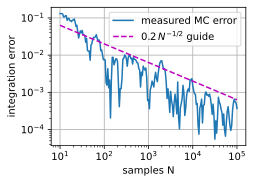

In [8]:
np.random.seed(1)
# E[e^{-X^2}], X ~ U[0, 1], by Monte Carlo vs a fine midpoint quadrature
# (midpoint is second-order: at eps=1e-4 its bias ~ 3e-10, below the print).
quad = float(np.sum(1e-4 * np.exp(-(np.arange(0., 1., 1e-4) + 5e-5) ** 2)))
draws = np.exp(-np.random.rand(100000) ** 2)
running = np.cumsum(draws) / np.arange(1., 100001.)   # running MC estimate
for n in [10, 100, 1000, 10000, 100000]:
    mc = float(running[n - 1])
    print(f'n={n:<7} Monte Carlo={mc:.5f}  error={abs(mc - quad):.1e}')
print(f'midpoint quadrature  ={quad:.5f}')

# Measured error of the running estimate vs the predicted sd(g)/sqrt(N)
# line, sampled at log-spaced N so the log-log plot stays light.
Ns = np.logspace(1., 5., 201)
err = np.abs(running[Ns.astype('int32') - 1] - quad)
d2l.plot(Ns, [err, 0.2 * Ns ** -0.5], 'samples N', 'integration error',
         xscale='log', yscale='log',
         legend=['measured MC error', '$0.2\\,N^{-1/2}$ guide'])

The running estimate closes in on the quadrature value as $n$
grows, unevenly, as randomness must: the $1/\sqrt{n}$ rate holds *in
expectation* (about $6\times 10^{-4}$ at $n=10^5$ for this integrand), and an
individual prefix can land lucky, as the $n=1000$ row here does, its error a
tenth of the predicted scale. The log-log plot shows the measured error
scattering around the $0.2\,N^{-1/2}$ guide line while tracking its slope of
$-\tfrac12$ across four decades. A second-order grid would beat that slope at
$d=2$ (error $N^{-1}$), tie it exactly at $d=4$ ($N^{-2/4}=N^{-1/2}$), and by
$d=6$ and $d=10$ flatten to slopes $-\tfrac13$ and $-\tfrac15$ and lose
badly; for the first-order left rule the break-even is already $d=2$. Past a
handful of dimensions, sampling is the only practical choice, which is the
quantitative face of the curse of dimensionality.

### Differentiating under the Integral Sign

::: {.callout-note title="Assumptions behind common calculus interchanges"}
Several formulas in this appendix are conditional statements. The following
sufficient conditions cover the cases used most often in machine learning:

* A derivative or Jacobian formula assumes differentiability on a neighborhood
  of the point. At a ReLU kink, autograd returns a library convention rather
  than a classical derivative.
* Equality of mixed partials and symmetry of the Hessian follow when the second
  partial derivatives are continuous on a neighborhood.
* Swapping two integrals is valid for a non-negative integrand (Tonelli) or an
  absolutely integrable one (Fubini). Conditional convergence needs separate
  care.
* Passing a limit or derivative through an integral is justified when an
  integrable dominating function controls the relevant sequence or derivative
  throughout a neighborhood of the parameter. Moving boundaries contribute the
  Leibniz boundary terms below.
* A change of variables requires a one-to-one differentiable map on the region
  of interest, or a partition into such regions, and a nonzero Jacobian
  determinant away from negligible boundary sets.

These are convenient sufficient conditions, not the weakest possible ones.
When a model changes support, approaches a singular distribution, or contains a
nonsmooth branch, pause and check the relevant theorem rather than applying the
formal rule mechanically.
:::

One more interchange matters in deep learning: moving a gradient through an
integral. When an integrand
depends on a parameter $\boldsymbol{\theta}$, we will routinely write

$$
\nabla_{\boldsymbol{\theta}} \int f(x, \boldsymbol{\theta})\,dx
= \int \nabla_{\boldsymbol{\theta}} f(x, \boldsymbol{\theta})\,dx .
$$

The swap needs a hypothesis. The standard sufficient condition, a consequence
of the **dominated convergence theorem** that we also state on faith
[@Folland.1999], is that, near the current $\boldsymbol{\theta}$, the
integrands' derivatives are bounded in magnitude by a single integrable
function of $x$. Many smooth, rapidly decaying densities used in deep learning comply, but the
condition must be checked rather than inferred from smoothness alone. Moving
support and increasingly sharp parameter-dependent spikes are two common ways
it can fail; failure is not limited to those cases.

When it is the *limits* of integration
that move, the correct derivative is known in closed form. The **Leibniz
rule** [@Folland.1999] states that

$$
\frac{d}{d\theta} \int_{a(\theta)}^{b(\theta)} f(x, \theta)\,dx
= \int_{a(\theta)}^{b(\theta)} \frac{\partial f}{\partial\theta}(x,\theta)\,dx
+ f\bigl(b(\theta), \theta\bigr)\,b'(\theta)
- f\bigl(a(\theta), \theta\bigr)\,a'(\theta) .
$$

The two boundary terms are precisely what the naive swap forgets: each moving
endpoint sweeps area in or out at the rate the limit moves, weighted by the
integrand's value there. A density supported on $[0, \theta]$ is the classic
trap: dropping the boundary term produces a confidently wrong gradient.

Two results we lean on later are direct applications of this swap.
Differentiating the normalization
$\int p_{\boldsymbol{\theta}}(x)\,dx = 1$ under the integral shows the score
$\nabla_{\boldsymbol{\theta}}\log p_{\boldsymbol{\theta}}$ has mean zero, the
seed of Fisher information (that section). This score
is a gradient with respect to the *parameters* $\boldsymbol{\theta}$; it is a
different object from the data score
$\nabla_{\mathbf{x}}\log p(\mathbf{x})$ that score matching estimates, which is
a gradient with respect to the data point. Applying the same swap to an expectation gives, when $g$ itself does not
depend on $\boldsymbol\theta$,

$$
\nabla_{\boldsymbol{\theta}}\,\mathbb{E}_{x\sim p_{\boldsymbol{\theta}}}[g(x)]
= \mathbb{E}\bigl[g(x)\,\nabla_{\boldsymbol{\theta}}\log
p_{\boldsymbol{\theta}}(x)\bigr].
$$

This is the **score-function**, or REINFORCE, identity
[@Williams.1992], at the heart of policy-gradient methods. If
$g(x,\boldsymbol\theta)$ also depends directly on the parameter, add the
ordinary term
$\mathbb E[\nabla_{\boldsymbol\theta}g(x,\boldsymbol\theta)]$ to the right.

#### Pathwise and Score-Function Gradients

The score-function identity is only one way to differentiate an expectation.
If a random variable can be generated by transforming parameter-free noise,

$$
\boldsymbol\epsilon\sim q,\qquad
x=T_{\boldsymbol\theta}(\boldsymbol\epsilon),
$$

then

$$
\nabla_{\boldsymbol\theta}
\mathbb E_{x\sim p_{\boldsymbol\theta}}[g(x,\boldsymbol\theta)]
=
\mathbb E_{\boldsymbol\epsilon\sim q}
\left[\frac{d}{d\boldsymbol\theta}
 g(T_{\boldsymbol\theta}(\boldsymbol\epsilon),\boldsymbol\theta)\right].
$$

This is the **pathwise**, or **reparameterization**, gradient. For example,
$X\sim\mathcal N(\mu,\sigma^2)$ can be written
$X=\mu+\sigma\epsilon$ with $\epsilon\sim\mathcal N(0,1)$; automatic
differentiation then follows an ordinary differentiable path from $\mu$ and
$\sigma$ to the sample. Variational autoencoders use exactly this device to
backpropagate through a Gaussian latent variable.

The two estimators are both Monte Carlo estimators of the same derivative, but
their variances can differ sharply. For
$L(\theta)=\mathbb E_{X\sim\mathcal N(\theta,1)}[X^2]=\theta^2+1$, the true
derivative is $2\theta$. With $X=\theta+\epsilon$, one sample contributes
$2X$ to the pathwise estimator. The score of the normal location family is
$\partial_\theta\log p_\theta(X)=X-\theta=\epsilon$, so REINFORCE contributes
$X^2\epsilon$. Subtracting any baseline $b$ that does not depend on $X$
leaves the expectation unchanged because $\mathbb E[\epsilon]=0$; choosing a
good baseline can remove substantial variance.

In [9]:
import numpy as onp
rng = onp.random.default_rng(7)
theta, n = 1.5, 200000
eps = rng.standard_normal(n)
x = theta + eps
pathwise = 2 * x
score = x**2 * eps
b_opt = theta**2 + 3                         # minimizes Var[(X^2-b) epsilon]
score_baseline = (x**2 - b_opt) * eps

def report(name, samples):
    se = samples.std(ddof=1) / onp.sqrt(len(samples))
    print(f'{name:22s} mean={samples.mean():.4f}  '
          f'sample sd={samples.std(ddof=1):.3f}  MC se={se:.4f}')

print(f'true derivative = {2 * theta:.4f}')
report('pathwise', pathwise)
report('score function', score)
report('score + baseline', score_baseline)

true derivative = 3.0000
pathwise               mean=3.0019  sample sd=1.998  MC se=0.0045
score function         mean=2.9974  sample sd=7.162  MC se=0.0160
score + baseline       mean=2.9924  sample sd=4.878  MC se=0.0109


All three sample means agree with $2\theta$ within Monte Carlo error. The
pathwise estimate is much less noisy on this smooth problem; the baseline
helps REINFORCE but does not generally close the gap. This is a common pattern,
not a universal ordering: variance depends on the model, transformation, and
integrand.

The score estimator remains valuable because it does not differentiate through
the sampled value. It therefore works for Bernoulli and categorical choices,
where an exact differentiable reparameterization is generally unavailable.
Continuous relaxations such as Gumbel--softmax
[@Jang.Gu.Poole.2017; @Maddison.Mnih.Teh.2017] create a differentiable
surrogate; straight-through estimators use a discrete forward value and a
surrogate backward derivative. These can reduce variance, but they are biased
for the original discrete objective unless a separate argument establishes
otherwise.

Both identities inherit the assumptions of differentiation under the integral
sign. The score form also assumes the relevant support does not move with
$\boldsymbol\theta$, or that the missing boundary terms are included. The
pathwise form requires a differentiable transformation and an integrable bound
for its derivative. In practice, “differentiate through randomness” therefore
means choosing an estimator, checking its assumptions, and reporting its
variance or Monte Carlo standard error—not merely asking an autodiff library
for a gradient.

## Summary

* The **definite integral** $\int_a^b f\,dx$ is the limit of Riemann rectangle
  sums the equation: the signed area under $f$, with negative
  contributions where $f<0$ or when the limits run backwards.
* The **fundamental theorem of calculus** the equation says the area-so-far
  function $F(x)=\int_a^x f$ has derivative $F'=f$. Integration is therefore
  differentiation reversed: $\int_a^b f = G(b)-G(a)$ for any antiderivative $G$.
* **Improper integrals** extend the definition to infinite domains as a limit;
  $\int_1^\infty x^{-p}\,dx$ converges exactly when $p>1$.
* **Integration by parts** the equation converts $\int u\,v'$ into a
  boundary term minus $\int u'\,v$: the product rule run backwards, and the
  standard device for moving a derivative onto the factor that can absorb it
  (score matching, expectations of products).
* **Change of variables** multiplies by the local stretch: $du/dx$ in one
  dimension the equation, the Jacobian determinant
  $|\det D\boldsymbol{\phi}|$ for a $C^1$-diffeomorphism in many
  the equation, the same volume-scaling read off the
  determinant.
* **Fubini's theorem** evaluates a multiple integral as iterated single integrals
  in either order, for absolutely integrable functions
  ($\int_U |f|\,d\mathbf{x} < \infty$).
* **Integration is the language of continuous probability:** a density is a
  normalized non-negative function $\int p = 1$, and an expectation is the integral
  $\int x\,p\,dx$. When it has no closed form, Monte Carlo estimates it by
  sampling, converging at the dimension-free rate $1/\sqrt{n}$, unlike a grid,
  whose cost explodes with dimension.
* Gradients of expectations admit two principal Monte Carlo estimators. The
  **score-function estimator** differentiates the log-density and works for
  discrete samples but can have high variance; the **pathwise estimator**
  differentiates a transformation of parameter-free noise and is usually
  preferred when such a smooth reparameterization exists. Baselines reduce
  score-estimator variance without changing its expectation.

## Exercises

1. For $X\sim\mathcal N(\theta,1)$ and $g(X)=X^4$, derive the pathwise and
   score-function gradient estimators. Verify analytically that both have mean
   $4\theta^3+12\theta$, then compare their Monte Carlo variances in NumPy.
2. Show that replacing $g(X)$ by $g(X)-b$ in
   the equation leaves the expected gradient
   unchanged when $b$ is independent of $X$. Derive the scalar baseline that
   minimizes the estimator's second moment.
3. Evaluate $\int_1^2 \tfrac{1}{x}\,dx$ using an antiderivative, then confirm with
   a Riemann sum.
4. Use the change-of-variables formula to integrate
   $\int_0^{\sqrt{\pi}} x\sin(x^2)\,dx$.
5. Compute $\int_{[0,1]^2} xy\,dx\,dy$ by Fubini's theorem.
6. For which $p$ does $\int_1^\infty x^{-p}\,dx$ converge? Verify the boundary
   $p=1$ numerically by watching the partial integrals as the upper limit grows.
7. Find the constant $c$ that makes $c\,e^{-x^2}$ a probability density on
   $\mathbb{R}$, then compute its mean and $\mathbb{E}[X^2]$.
8. Let $f(x,y) = (x^2-y^2)/(x^2+y^2)^2$. Compute the iterated integrals
   $\int_0^1\!\bigl(\int_0^1 f\,dx\bigr)dy$ and $\int_0^1\!\bigl(\int_0^1
   f\,dy\bigr)dx$ over $[0,1]^2$ and confirm they equal $-\tfrac{\pi}{4}$ and
   $+\tfrac{\pi}{4}$. Why does this not contradict Fubini's theorem? (Hint:
   $\frac{\partial}{\partial x}\frac{-x}{x^2+y^2} = f(x,y)$; the singularity at the
   origin breaks absolute integrability.)
9. Estimate $\int_0^1 e^{-x^2}\,dx$ by Monte Carlo (average $e^{-x_i^2}$ over
   $x_i$ uniform on $[0,1]$) and compare with a Riemann sum.
10. Use integration by parts the equation twice to evaluate
   $\int_0^\infty u^2 e^{-u}\,du$, the second moment behind the exponential
   distribution's variance in that section. The integral you
   have computed is $\Gamma(3)$, an instance of the **Gamma function**
   $\Gamma(t) = \int_0^\infty u^{t-1}e^{-u}\,du$; the same
   integration-by-parts step, run once at general $t$, gives the recursion
   $\Gamma(t+1) = t\,\Gamma(t)$ and hence $\Gamma(n+1) = n!$, the function that
   names the Gamma distribution of that section.

[Discussions](https://d2l.discourse.group/t/1092)